## Hypothesis Testing & Visualisation — Employee Attrition ##

## Objectives

* Visualise the 6 attrition hypotheses (H1-H6) using the cleaned employee dataset
* Show one chart per hypothesis and state the result

## Inputs

* `Dataset/Clean_Dataset/Employee_Attrition_Cleaned.csv` — cleaned employee attrition dataset

## Outputs

* One chart per hypothesis (H1-H6), grouped by business requirement

## Additional Comments

| BR | Hypotheses |
|---|---|
| BR1 - Stress & unhappiness | H1 Overtime, H3 Job Satisfaction, H5 Work-Life Balance |
| BR2 - Pay & promotions | H2 Monthly Income, H4 Years at Company |
| BR3 - Who is most at risk | H6 Age |



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/shiffzz/Documents/Projects/HR_EMPLOYEE_ATTRITION_IBM/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/shiffzz/Documents/Projects/HR_EMPLOYEE_ATTRITION_IBM'

# Import libraries and packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [24]:
df = pd.read_csv("Dataset/Clean_Dataset/Employee_Attrition_Cleaned.csv")




In [25]:
df.shape

(1470, 32)

# Section 1 — BR1: Stress & Unhappiness

## H1 — Overtime Hypothesis


In [26]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Encoded
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,...,1,0,1,8,0,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,...,4,1,3,10,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,...,2,0,3,7,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,...,3,0,3,8,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,...,4,1,3,6,3,2,2,2,2,0


In [27]:
rate_by_ot = df.groupby("OverTime")["Attrition_Encoded"].mean() * 100
rate_by_ot

OverTime
No     10.436433
Yes    30.528846
Name: Attrition_Encoded, dtype: float64

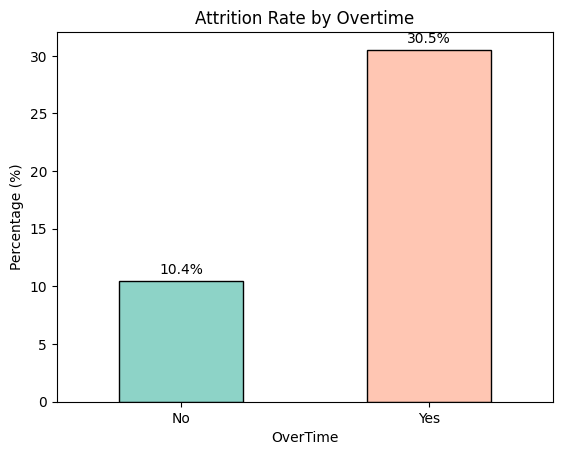

In [28]:
# 1. Calculate the percentages
rate_by_ot = df.groupby('OverTime')['Attrition_Encoded'].mean() * 100

# 2. Create the plot and save it to a variable 'ax'
ax = rate_by_ot.plot(kind='bar', color=['#8dd3c7', "#ffc6b3"], edgecolor='black')

# 3. AUTOMATICALLY ADD LABELS ON TOP OF THE BARS
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# 4. Add titles and show
import matplotlib.pyplot as plt
plt.title("Attrition Rate by Overtime")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0) # Keeps 'Yes' and 'No' upright and easy to read
plt.show()





**Takeaway:** overtime workers leave at roughly 3x the rate of non-overtime workers (30.5% vs 10.4%). **H1 confirmed** — supports BR1.


# Section 2 — Monthly Income Hypothesis (H2)

Business Requirement 2 (pay and promotions). **Hypothesis:** employees leave
because they feel underpaid.


In [10]:
df.groupby("Attrition_Encoded")["MonthlyIncome"].median()

Attrition_Encoded
0    5204.0
1    3202.0
Name: MonthlyIncome, dtype: float64

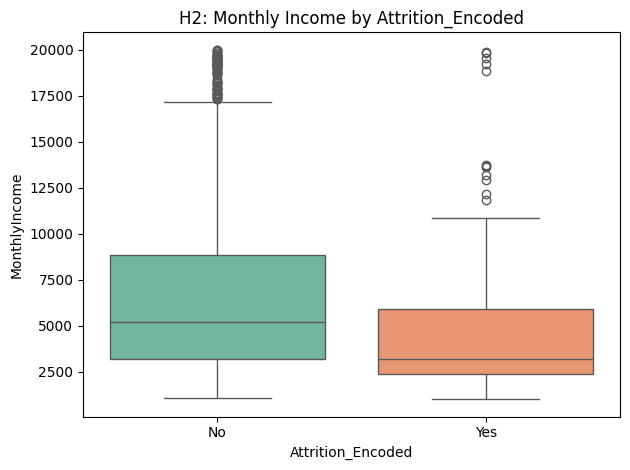

In [11]:
# The same plot command
ax = sns.boxplot(x="Attrition_Encoded", y="MonthlyIncome", data=df,
                  hue="Attrition_Encoded", palette="Set2", legend=False, order=[0, 1])

# FIX: Set the positions first, THEN apply the text labels safely
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

ax.set_xlabel("Attrition_Encoded")
plt.title("H2: Monthly Income by Attrition_Encoded")
plt.tight_layout()
plt.show()


## H3 — Job Satisfaction Hypothesis
Business Requirement 1 (stress and unhappiness). **Hypothesis:** being unhappy
with daily tasks leads to people leaving.


Section 1 content

In [12]:
# normalize="index" turns each satisfaction-level row into a percentage,
# so groups of different sizes can be compared fairly
sat_ct = pd.crosstab(df["JobSatisfaction"], df["Attrition_Encoded"], normalize="index") * 100
sat_ct.columns = ["No", "Yes"]
sat_ct

,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [13]:
# 1. Create a percentage cross-tabulation table
# Note: Use 'Attrition' or 'Attrition_Encoded' depending on your exact column name
satisfaction_pct = pd.crosstab(
    df['JobSatisfaction'], 
    df['Attrition_Encoded'], 
    normalize='index'
) * 100

# 2. Display the clean result rounded to 1 decimal place
print("--- Attrition Split by Job Satisfaction Level (%) ---")
print(satisfaction_pct.round(1))

--- Attrition Split by Job Satisfaction Level (%) ---
Attrition_Encoded     0     1
JobSatisfaction              
1                  77.2  22.8
2                  83.6  16.4
3                  83.5  16.5
4                  88.7  11.3


---

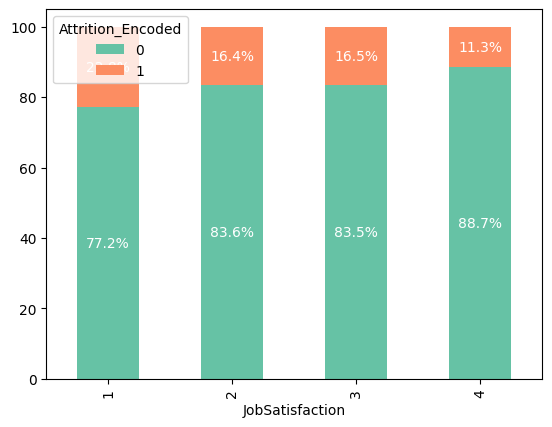

In [14]:
# 1. Create and plot the chart in one line
ax = pd.crosstab(df['JobSatisfaction'], df['Attrition_Encoded'], normalize='index').mul(100).plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'])

# 2. Add the percentage labels inside the blocks
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white')


**Takeaway:** attrition drops from 22.8% (lowest satisfaction) to 11.3% (highest). **H3 is confirmed** — supports BR1.

---

# Section 4 — Years at Company Hypothesis (H4)

Business Requirement 2 (pay and promotions). **Hypothesis:** people feel
ignored after their first few years and decide to leave.

In [15]:
df.groupby("Attrition_Encoded")["YearsAtCompany"].median()


Attrition_Encoded
0    6.0
1    3.0
Name: YearsAtCompany, dtype: float64

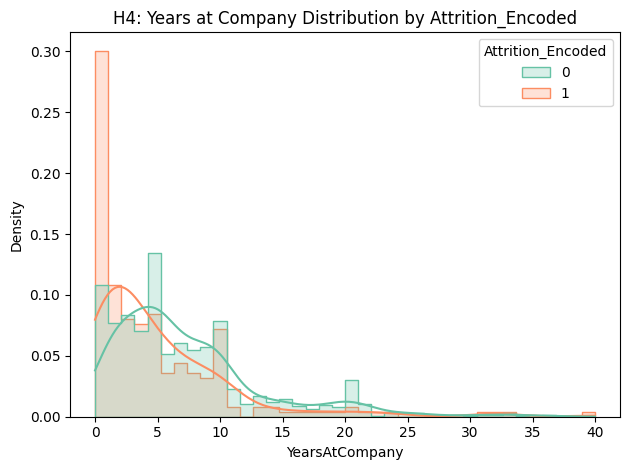

In [16]:
# A box plot would only show the median gap; a histogram/KDE keeps the full
# shape so we can see WHEN people tend to leave, not just a typical tenure
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition_Encoded", stat="density",
             common_norm=False, kde=True, palette="Set2", element="step")
plt.title("H4: Years at Company Distribution by Attrition_Encoded")
plt.tight_layout()
plt.show()

**Takeaway:** leavers have a median tenure of 3 years vs. 6 for stayers, concentrated early on. **H4 confirmed** (early-tenure risk) — supports BR2.

# Section 5 — Work-Life Balance Hypothesis (H5)

Business Requirement 1 (stress and unhappiness). **Hypothesis:** no time for
personal life outside work forces employees to leave.


In [17]:
wlb_rate = df.groupby("WorkLifeBalance")["Attrition_Encoded"].mean() * 100
wlb_rate


WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition_Encoded, dtype: float64

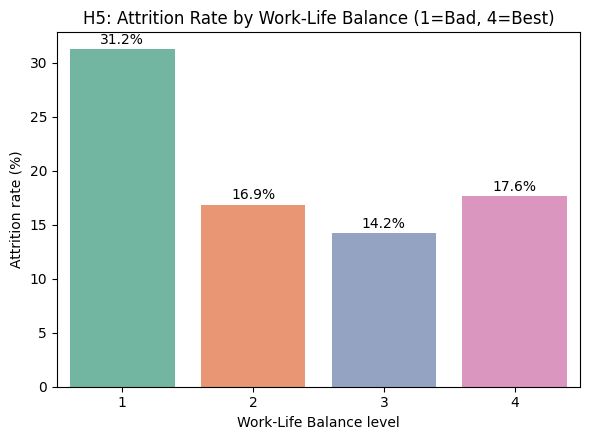

In [18]:
plt.figure(figsize=(6, 4.5))
ax = sns.barplot(x=wlb_rate.index, y=wlb_rate.values, hue=wlb_rate.index,
                  palette="Set2", legend=False)
ax.set_title("H5: Attrition Rate by Work-Life Balance (1=Bad, 4=Best)")
ax.set_ylabel("Attrition rate (%)")
ax.set_xlabel("Work-Life Balance level")
for i, v in enumerate(wlb_rate.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


**Takeaway:** the worst work-life balance group leaves at 31.2% — roughly double every other group. **H5 confirmed** at the low end — supports BR1.

---

# Section 6 — Age Hypothesis (H6)

Business Requirement 3 (who is most likely to leave). **Hypothesis:** younger
workers quit more often than older, more settled workers.


In [19]:
df.groupby("Attrition_Encoded")["Age"].median()


Attrition_Encoded
0    36.0
1    32.0
Name: Age, dtype: float64

--- Median Ages ---
Attrition_Encoded
0    36.0
1    32.0
Name: Age, dtype: float64


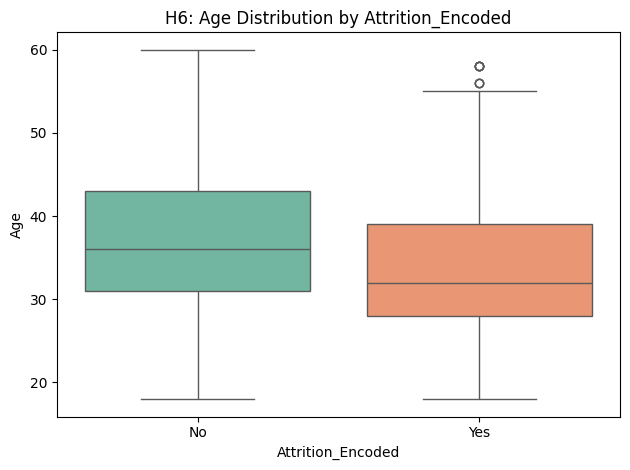

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot the chart cleanly
ax = sns.boxplot(
    x="Attrition_Encoded", y="Age", data=df, 
    hue="Attrition_Encoded", palette="Set2", legend=False, order=[0, 1]
)

# 2. Fix the labels safely in a single line (No Warnings!)
ax.set(xticks=[0, 1], xticklabels=["No", "Yes"], xlabel="Attrition_Encoded")

# 3. Print the exact medians right under the chart
print("--- Median Ages ---")
print(df.groupby('Attrition_Encoded')['Age'].median())

plt.title("H6: Age Distribution by Attrition_Encoded")
plt.tight_layout()
plt.show()


**Takeaway:** leavers are younger on average (median 32 vs. 36). **H6 confirmed** — supports BR3.

# Section 7 — Cross-cutting check: correlation with Attrition_Encoded

In [21]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()["Attrition_Encoded"].sort_values(ascending=False)
corr.head(8)

Attrition_Encoded     1.000000
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
HourlyRate           -0.006846
EmployeeNumber       -0.010577
PercentSalaryHike    -0.013478
Name: Attrition_Encoded, dtype: float64

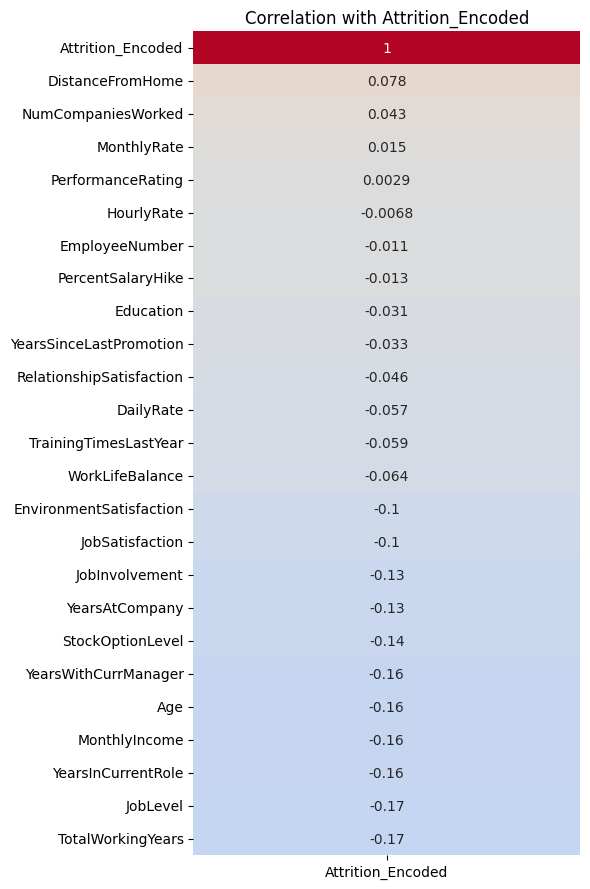

In [22]:
plt.figure(figsize=(6, 9))
sns.heatmap(corr.to_frame(), annot=True, cmap="coolwarm", center=0, cbar=False)
plt.title("Correlation with Attrition_Encoded")
plt.tight_layout()
plt.show()

**Takeaway:** `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, and
`MonthlyIncome` show the strongest (negative) correlations with
`Attrition_Encoded` — more senior, longer-tenured, higher-paid employees are
least likely to leave. This reinforces H2 and H4.


NOTE
* All notebook cells should be run top-down.
* `Attrition_Encoded` (1 = left, 0 = stayed) is used for every grouping and
  plot in this notebook. Chart tick labels are relabelled to "No"/"Yes" purely
  for readability — no separate Yes/No column exists in the 32-column dataset.

# Conclusions and Next Steps


## Summary of results

| Hypothesis | Business Requirement | Result | Strength of signal |
|---|---|---|---|
| H1 Overtime | BR1 | Confirmed | Strong (3x attrition rate) |
| H2 Monthly Income | BR2 | Confirmed | Strong (~$2,000 median gap) |
| H3 Job Satisfaction | BR1 | Confirmed | Moderate |
| H4 Years at Company | BR2 | Confirmed (early-tenure risk) | Moderate-Strong |
| H5 Work-Life Balance | BR1 | Confirmed at low end | Moderate |
| H6 Age | BR3 | Confirmed | Moderate |

## For HR

The two strongest levers are reducing overtime dependency and addressing pay
gaps for at-risk roles, with a secondary focus on early-tenure onboarding and
retention programmes for employees in their first 1-3 years.





# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [23]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)